In [3]:
! pip install ultralytics

In [4]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-80GB


In [5]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import numpy as np
import pandas as pd
import cv2
import yaml
from collections import Counter
%matplotlib inline

In [20]:
train_image="/home/mohammad/datasets/VisDrone2019-DET-train/VisDrone2019-DET-train/images/"
train_label="/home/mohammad/datasets/VisDrone2019-DET-train/VisDrone2019-DET-train/labels/"

valid_image="/home/mohammad/datasets/VisDrone2019-DET-val/VisDrone2019-DET-val/images/"
valid_label="/home/mohammad/datasets/VisDrone2019-DET-val/VisDrone2019-DET-val/labels/"

test_image="/home/mohammad/datasets/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev/images/"
test_label="/home/mohammad/datasets/VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev/labels/"

In [21]:
yaml_path='/home/mohammad/datasets/VisDrone.yaml'
with open(yaml_path,"r") as file:
    data=yaml.safe_load(file)
print(data)

{'path': '../datasets/VisDrone', 'train': 'VisDrone2019-DET-train/images', 'val': 'VisDrone2019-DET-val/images', 'test': 'VisDrone2019-DET-test-dev/images', 'names': {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'}, 'download': 'import os\nfrom pathlib import Path\n\nfrom ultralytics.utils.downloads import download\n\ndef visdrone2yolo(dir):\n    from PIL import Image\n    from tqdm import tqdm\n\n    def convert_box(size, box):\n        # Convert VisDrone box to YOLO xywh box\n        dw = 1. / size[0]\n        dh = 1. / size[1]\n        return (box[0] + box[2] / 2) * dw, (box[1] + box[3] / 2) * dh, box[2] * dw, box[3] * dh\n\n    (dir / \'labels\').mkdir(parents=True, exist_ok=True)  # make labels directory\n    pbar = tqdm((dir / \'annotations\').glob(\'*.txt\'), desc=f\'Converting {dir}\')\n    for f in pbar:\n        img_size = Image.open((dir / \'images\' / f.name).with_suffix(\'.jpg\')).size\n

In [22]:
class_names = {
    0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van',
    5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'
}

def count_classes(label_dir):
    counts = Counter()
    for file in os.listdir(label_dir):
        if file.endswith(".txt"):
            with open(os.path.join(label_dir, file)) as f:
                for line in f:
                    values = line.strip().split()
                    if len(values) == 5:
                        cls = int(values[0])
                        counts[cls] += 1
    return counts

train_counts = count_classes(train_label)
valid_counts = count_classes(valid_label)
test_counts  = count_classes(test_label)

print("#"*150)
print("Train counts:", {class_names[k]: v for k, v in train_counts.items()})
print("#"*150)
print("Validation counts:", {class_names[k]: v for k, v in valid_counts.items()})
print("#"*150)
print("Test counts:", {class_names[k]: v for k, v in test_counts.items()})
print("#"*150)

######################################################################################################################################################
Train counts: {'car': 144867, 'truck': 12875, 'van': 24956, 'pedestrian': 79337, 'bus': 5926, 'people': 27059, 'motor': 29647, 'awning-tricycle': 3246, 'bicycle': 10480, 'tricycle': 4812}
######################################################################################################################################################
Validation counts: {'truck': 750, 'car': 14064, 'pedestrian': 8844, 'van': 1975, 'tricycle': 1045, 'bus': 251, 'bicycle': 1287, 'motor': 4886, 'people': 5125, 'awning-tricycle': 532}
######################################################################################################################################################
Test counts: {'car': 28074, 'truck': 2659, 'motor': 5845, 'bicycle': 1302, 'awning-tricycle': 599, 'van': 5771, 'people': 6376, 'pedestrian': 21006, 'bus': 2940, 'tricycle': 53

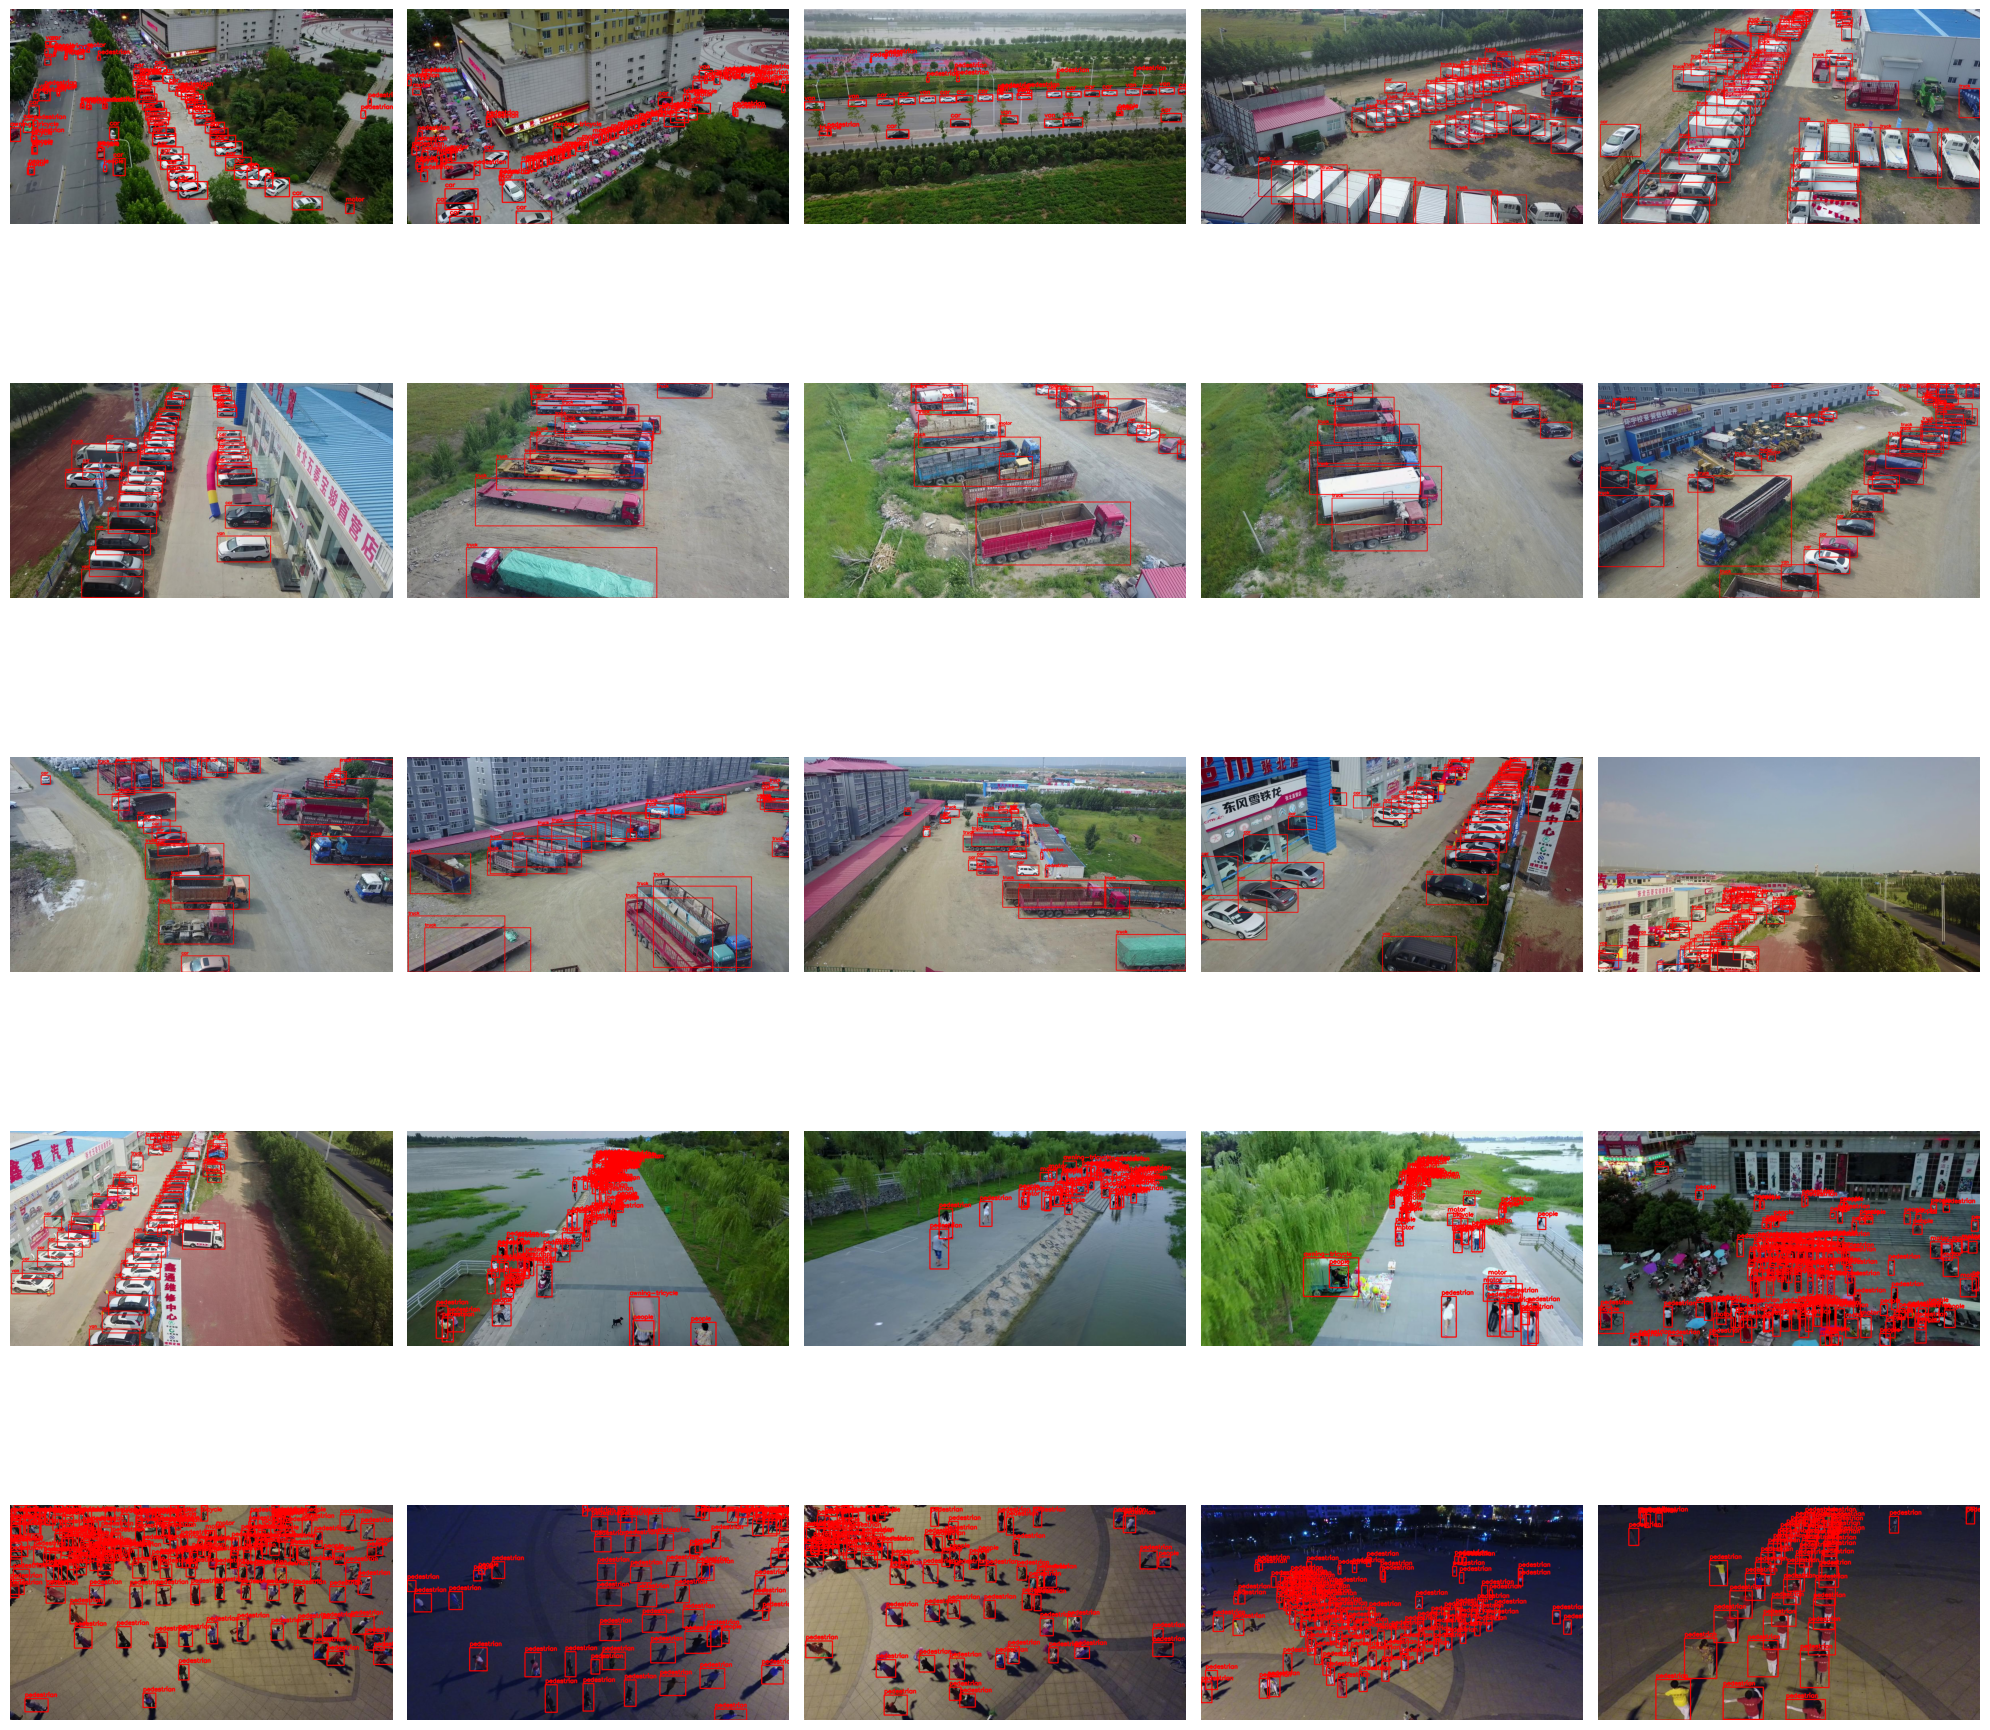

In [23]:
class_names = ["pedestrian", "people", "bicycle", "car", "van","truck", "tricycle", "awning-tricycle", "bus", "motor"]

image_files = sorted(os.listdir(train_image))[:25]

plt.figure(figsize=(20, 20))

for idx, img_file in enumerate(image_files, 1):
    img_path = os.path.join(train_image, img_file)
    label_path = os.path.join(train_label, img_file.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                values = line.strip().split()
                if len(values) == 5:
                    cls, x, y, bw, bh = map(float, values)
                    cls = int(cls)
                    x1 = int((x - bw / 2) * w)
                    y1 = int((y - bh / 2) * h)
                    x2 = int((x + bw / 2) * w)
                    y2 = int((y + bh / 2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, class_names[cls], (x1, max(15, y1 - 5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    plt.subplot(5, 5, idx)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()


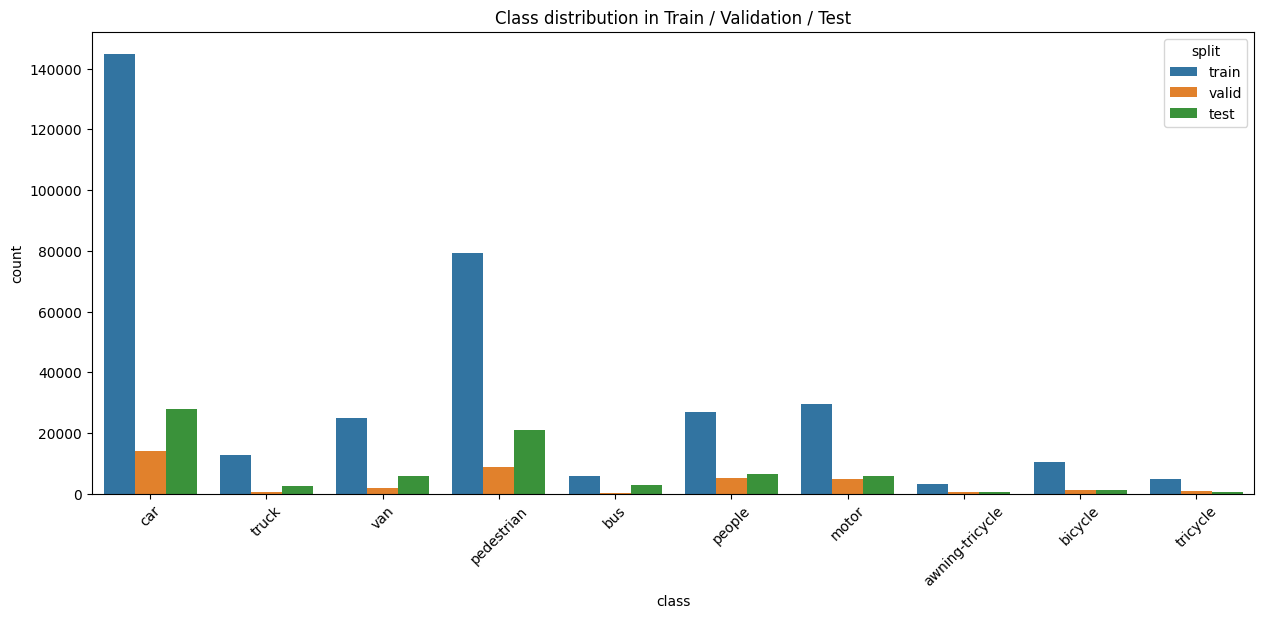

In [24]:
def count_classes(label_dir, split_name):
    counts = []
    for file in os.listdir(label_dir):
        if not file.endswith(".txt"):
            continue
        with open(os.path.join(label_dir, file)) as f:
            for line in f:
                values = line.strip().split()
                if len(values) == 5:   # ignore comments/invalid
                    cls = int(values[0])
                    counts.append((split_name, class_names[cls]))
    return counts

data = []
data += count_classes(train_label, "train")
data += count_classes(valid_label, "valid")
data += count_classes(test_label, "test")

df = pd.DataFrame(data, columns=["split", "class"])

plt.figure(figsize=(15,6))
sns.countplot(data=df, x="class", hue="split")
plt.xticks(rotation=45)
plt.title("Class distribution in Train / Validation / Test")
plt.show()

In [26]:
image=cv2.imread("/home/mohammad/datasets/VisDrone2019-DET-train/VisDrone2019-DET-train/images/0000002_00005_d_0000014.jpg")
height,width,channels=image.shape
print("Height:", height)
print("Width:", width)
print("Channels:", channels)

Height: 540
Width: 960
Channels: 3



image 1/1 /home/mohammad/datasets/VisDrone2019-DET-train/VisDrone2019-DET-train/images/0000007_05999_d_0000038.jpg: 384x640 15 cars, 1 truck, 55.8ms
Speed: 2.4ms preprocess, 55.8ms inference, 15.3ms postprocess per image at shape (1, 3, 384, 640)


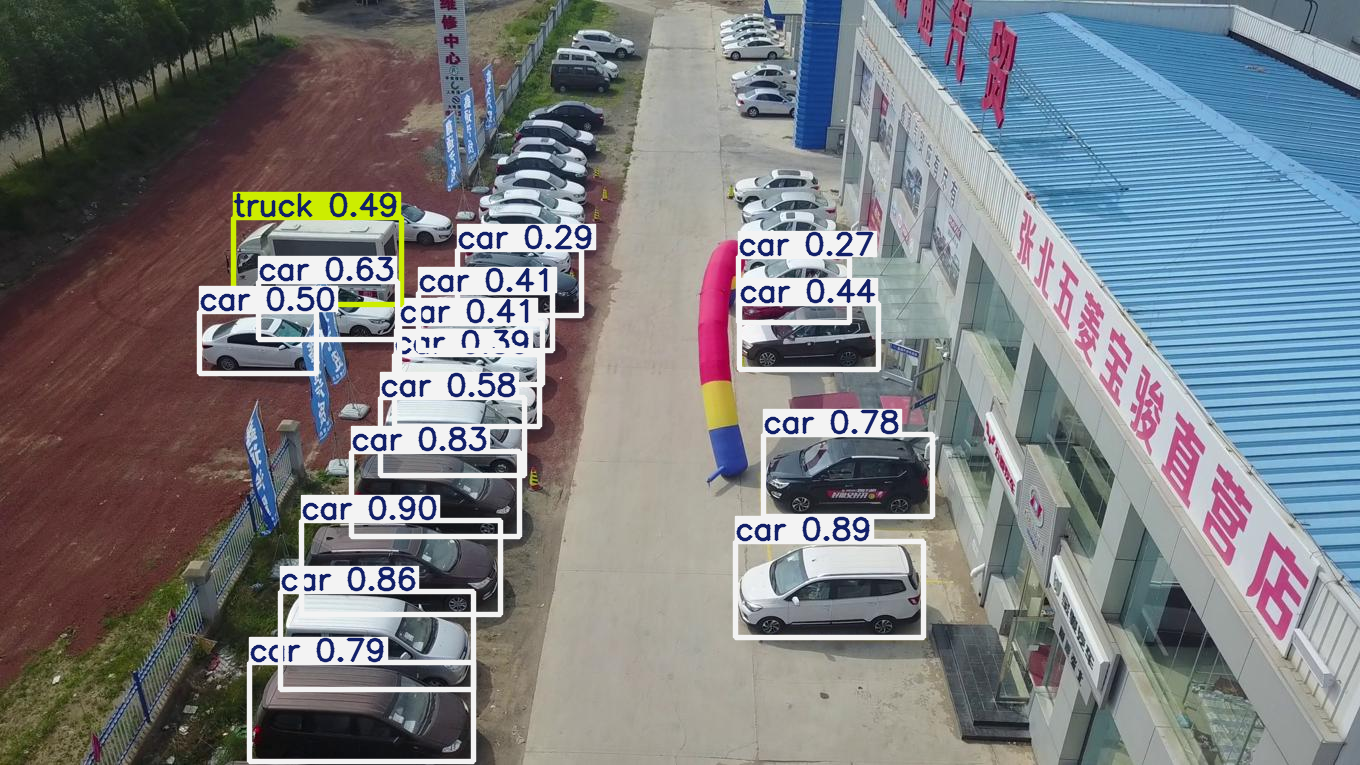

In [27]:
model = YOLO("yolov10b.pt")
results = model("/home/mohammad/datasets/VisDrone2019-DET-train/VisDrone2019-DET-train/images/0000007_05999_d_0000038.jpg"
)
results[0].show()

In [28]:
yaml_content = """
path: /home/mohammad/datasets

train: VisDrone2019-DET-train/VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-dev/VisDrone2019-DET-test-dev/images

nc: 2

names:
  0: person
  1: car
"""

yaml_path = "/home/mohammad/datasets/visdrone.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("visdrone.yaml created at:", yaml_path)

visdrone.yaml created at: /home/mohammad/datasets/visdrone.yaml


In [29]:
history = model.train(
    data=yaml_path,

    epochs=50,
    batch=-1,

    optimizer="AdamW",
    lr0=0.001,

    project="my_project",
    name="visdrone_person_car",

    patience=15,

    imgsz=640,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=5,
    translate=0.1,
    scale=0.5,

    mosaic=1.0,
    mixup=0.1,

    fliplr=0.5,

    cache=True,
)

Ultralytics 8.4.53 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-80GB, 81154MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/mohammad/datasets/visdrone.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov10b.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_person_car, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW,

In [ ]:

import os
from PIL import Image

folder_path = "/home/mohammad/AdvanceML/my_project/train2"
image_files = [
    "BoxF1_curve.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "labels.jpg",
    "labels_correlogram.jpg",
    "results.png",
    "train_batch0.jpg",
    "train_batch1.jpg",
    "train_batch2.jpg",
    "val_batch0_labels.jpg",
    "val_batch0_pred.jpg",
    "val_batch1_labels.jpg",
    "val_batch1_pred.jpg",
    "val_batch2_labels.jpg",
    "val_batch2_pred.jpg"
]

for file in image_files:
    img_path = os.path.join(folder_path, file)
    img = Image.open(img_path)
    plt.figure(figsize=(20, 8))
    plt.imshow(img)
    plt.title(file.replace("_", " ").split(".")[0])
    plt.axis("off")
    plt.show()


requirements: Ultralytics requirement ['pi-heif'] not found, attempting AutoUpdate...
WARNING ⚠️ 


ModuleNotFoundError: No module named 'pi_heif'

In [ ]:
df=pd.read_csv("/kaggle/working/my_project/train3/results.csv")

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.columns = df.columns.str.strip()

fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))

# Plot the columns using seaborn
sns.lineplot(x='epoch', y='train/box_loss', data=df, ax=axs[0,0])
sns.lineplot(x='epoch', y='train/cls_loss', data=df, ax=axs[0,1])
sns.lineplot(x='epoch', y='train/dfl_loss', data=df, ax=axs[1,0])
sns.lineplot(x='epoch', y='metrics/precision(B)', data=df, ax=axs[1,1])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=df, ax=axs[2,0])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=df, ax=axs[2,1])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=df, ax=axs[3,0])
sns.lineplot(x='epoch', y='val/box_loss', data=df, ax=axs[3,1])
sns.lineplot(x='epoch', y='val/cls_loss', data=df, ax=axs[4,0])
sns.lineplot(x='epoch', y='val/dfl_loss', data=df, ax=axs[4,1])

# Set titles and axis labels for each subplot
axs[0,0].set(title='Train Box Loss')
axs[0,1].set(title='Train Class Loss')
axs[1,0].set(title='Train DFL Loss')
axs[1,1].set(title='Metrics Precision (B)')
axs[2,0].set(title='Metrics Recall (B)')
axs[2,1].set(title='Metrics mAP50 (B)')
axs[3,0].set(title='Metrics mAP50-95 (B)')
axs[3,1].set(title='Validation Box Loss')
axs[4,0].set(title='Validation Class Loss')
axs[4,1].set(title='Validation DFL Loss')


plt.suptitle('Training Metrics and Loss', fontsize=24)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Define a color palette for consistency
colors = sns.color_palette("husl", 8)

# Strip whitespace from column names (just in case)
df.columns=df.columns.str.strip()

# Create figure with subplots for original plots (5 rows, 2 columns)
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 20), dpi=100)

# Original plots
sns.lineplot(x='epoch', y='train/box_loss', data=df, ax=axs[0, 0], color=colors[0], linewidth=2)
sns.lineplot(x='epoch', y='train/cls_loss', data=df, ax=axs[0, 1], color=colors[1], linewidth=2)
sns.lineplot(x='epoch', y='train/dfl_loss', data=df, ax=axs[1, 0], color=colors[2], linewidth=2)
sns.lineplot(x='epoch', y='metrics/precision(B)', data=df, ax=axs[1, 1], color=colors[3], linewidth=2)
sns.lineplot(x='epoch', y='metrics/recall(B)', data=df, ax=axs[2, 0], color=colors[4], linewidth=2)
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=df, ax=axs[2, 1], color=colors[5], linewidth=2)
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=df, ax=axs[3, 0], color=colors[6], linewidth=2)
sns.lineplot(x='epoch', y='val/box_loss', data=df, ax=axs[3, 1], color=colors[0], linewidth=2)
sns.lineplot(x='epoch', y='val/cls_loss', data=df, ax=axs[4, 0], color=colors[1], linewidth=2)
sns.lineplot(x='epoch', y='val/dfl_loss', data=df, ax=axs[4, 1], color=colors[2], linewidth=2)

# Set titles and labels
axs[0, 0].set(title='Train Box Loss', xlabel='Epoch', ylabel='Loss')
axs[0, 1].set(title='Train Class Loss', xlabel='Epoch', ylabel='Loss')
axs[1, 0].set(title='Train DFL Loss', xlabel='Epoch', ylabel='Loss')
axs[1, 1].set(title='Precision (B)', xlabel='Epoch', ylabel='Precision')
axs[2, 0].set(title='Recall (B)', xlabel='Epoch', ylabel='Recall')
axs[2, 1].set(title='mAP50 (B)', xlabel='Epoch', ylabel='mAP50')
axs[3, 0].set(title='mAP50-95 (B)', xlabel='Epoch', ylabel='mAP50-95')
axs[3, 1].set(title='Validation Box Loss', xlabel='Epoch', ylabel='Loss')
axs[4, 0].set(title='Validation Class Loss', xlabel='Epoch', ylabel='Loss')
axs[4, 1].set(title='Validation DFL Loss', xlabel='Epoch', ylabel='Loss')

# Main title and layout
plt.suptitle('Training and Validation Metrics\n\n')
plt.tight_layout()

# Additional Plots
# 1. Train vs Validation Loss Comparison
fig_comp, axs_comp = plt.subplots(1, 3, figsize=(15, 5), dpi=100)
sns.lineplot(x='epoch', y='train/box_loss', data=df, label='Train', ax=axs_comp[0], color=colors[0], linewidth=2)
sns.lineplot(x='epoch', y='val/box_loss', data=df, label='Validation', ax=axs_comp[0], color=colors[1], linewidth=2)
axs_comp[0].set(title='Box Loss: Train vs Val', xlabel='Epoch', ylabel='Box Loss')
axs_comp[0].legend()

sns.lineplot(x='epoch', y='train/cls_loss', data=df, label='Train', ax=axs_comp[1], color=colors[0], linewidth=2)
sns.lineplot(x='epoch', y='val/cls_loss', data=df, label='Validation', ax=axs_comp[1], color=colors[1], linewidth=2)
axs_comp[1].set(title='Class Loss: Train vs Val', xlabel='Epoch', ylabel='Class Loss')
axs_comp[1].legend()

sns.lineplot(x='epoch', y='train/dfl_loss', data=df, label='Train', ax=axs_comp[2], color=colors[0], linewidth=2)
sns.lineplot(x='epoch', y='val/dfl_loss', data=df, label='Validation', ax=axs_comp[2], color=colors[1], linewidth=2)
axs_comp[2].set(title='DFL Loss: Train vs Val', xlabel='Epoch', ylabel='DFL Loss')
axs_comp[2].legend()

plt.tight_layout()
plt.show()

# 2. Precision vs Recall Scatter Plot
fig_pr, ax_pr = plt.subplots(figsize=(10, 10), dpi=100)
sns.scatterplot(x='metrics/recall(B)', y='metrics/precision(B)', hue='epoch', size='epoch',palette='viridis', data=df, ax=ax_pr, legend='full')
ax_pr.set(title='Precision vs Recall', xlabel='Recall (B)', ylabel='Precision (B)')
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 3. Total Loss
df['train/total_loss'] = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
df['val/total_loss'] = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']

fig_total, ax_total = plt.subplots(figsize=(10, 5), dpi=100)
sns.lineplot(x='epoch', y='train/total_loss', data=df, label='Train', ax=ax_total, color=colors[0], linewidth=2)
sns.lineplot(x='epoch', y='val/total_loss', data=df, label='Validation', ax=ax_total, color=colors[1], linewidth=2)
ax_total.set(title='Total Loss: Train vs Val', xlabel='Epoch', ylabel='Total Loss')
ax_total.legend()
plt.tight_layout()
plt.show()
# 4. mAP50 vs mAP50-95
fig_map, ax_map = plt.subplots(figsize=(10, 5), dpi=100)
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=df, label='mAP50', ax=ax_map, color=colors[5], linewidth=2)
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=df, label='mAP50-95', ax=ax_map, color=colors[6], linewidth=2)
ax_map.set(title='mAP50 vs mAP50-95', xlabel='Epoch', ylabel='mAP')
ax_map.legend()
plt.tight_layout()
plt.show()

# 5. Loss Components Contribution (Stacked Area Plot)
fig_stack, axs_stack = plt.subplots(1, 2, figsize=(15, 5), dpi=100)
axs_stack[0].stackplot(df['epoch'],
                       df['train/box_loss'],
                       df['train/cls_loss'],
                       df['train/dfl_loss'],
                       labels=['Box Loss', 'Class Loss', 'DFL Loss'],
                       colors=colors[:3])
axs_stack[0].set(title='Train Loss Components', xlabel='Epoch', ylabel='Loss')
axs_stack[0].legend(loc='upper right')

axs_stack[1].stackplot(df['epoch'],
                       df['val/box_loss'],
                       df['val/cls_loss'],
                       df['val/dfl_loss'],
                       labels=['Box Loss', 'Class Loss', 'DFL Loss'],
                       colors=colors[:3])
axs_stack[1].set(title='Validation Loss Components', xlabel='Epoch', ylabel='Loss')
axs_stack[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

# 6. Smoothed Metrics (e.g., mAP50)
model_result_smoothed = df.rolling(window=3, center=True).mean()
fig_smooth, ax_smooth = plt.subplots(figsize=(10, 5), dpi=100)
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=df, label='Original', alpha=0.3, ax=ax_smooth, color=colors[5])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=model_result_smoothed, label='Smoothed', ax=ax_smooth, color=colors[5], linewidth=2)
ax_smooth.set(title='Smoothed mAP50 (B)', xlabel='Epoch', ylabel='mAP50 (B)')
ax_smooth.legend()
plt.tight_layout()
plt.show()

# 7. Metrics Correlation Heatmap
metrics_cols = ['train/box_loss', 'train/cls_loss', 'train/dfl_loss', 
                'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 
                'metrics/precision(B)', 'metrics/recall(B)', 
                'metrics/mAP50(B)', 'metrics/mAP50-95(B)']
correlation_matrix = df[metrics_cols].corr()

fig_corr, ax_corr = plt.subplots(figsize=(15, 8), dpi=100)
sns.heatmap(correlation_matrix, annot=True, cmap='gnuplot', fmt='.2f', ax=ax_corr, cbar_kws={'label': 'Correlation'})
ax_corr.set(title='Metrics Correlation Heatmap')
plt.tight_layout()
plt.show()

# 8. Training Time Plot (using 'time' column)
fig_time, ax_time = plt.subplots(figsize=(10, 5), dpi=100)
sns.lineplot(x='epoch', y='time', data=df, ax=ax_time, color=colors[7], linewidth=2)
ax_time.set(title='Training Time per Epoch', xlabel='Epoch', ylabel='Time (seconds)')
plt.tight_layout()
plt.show()

# Display the original plot
plt.figure(fig)
plt.show()

In [ ]:
best_model="/kaggle/working/my_project/train3/weights/best.pt"
test_model=YOLO(best_model)
metrics=test_model.val(split="test")


for metric_name, value in metrics.results_dict.items():
    print(f"{metric_name}: {value}")


In [ ]:
def resize_image(image, size=(640, 640)):
    return cv2.resize(image, size)

test_images_path = '/home/mohammad/datasets/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images'
image_files = [f for f in os.listdir(test_images_path) if f.lower().endswith('.jpg')]

step = max(1, len(image_files) // 49)
selected_images = image_files[::step][:49]

fig, axes = plt.subplots(7, 7, figsize=(24, 24))
fig.suptitle('Test Set Predictions (7x7 Grid)', fontsize=24)

for ax, img_name in zip(axes.flatten(), selected_images):
    img_path = os.path.join(test_images_path, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        img_resized = resize_image(img)
        results = test_model.predict(source=img_resized, imgsz=640, conf=0.5)
        annotated = results[0].plot(line_width=1)
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        ax.imshow(annotated_rgb)
    else:
        ax.text(0.5, 0.5, 'Load failed', ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO
import cv2


# Load your trained YOLO model
best_model = "/kaggle/working/my_project/train3/weights/best.pt"
model = YOLO(best_model)

# Path to test images
test_images_path = "/home/mohammad/datasets/VisDrone_Dataset/VisDrone2019-DET-test-dev/images"

# Get first 15 images
all_images = sorted(os.listdir(test_images_path))[:15]
image_paths = [os.path.join(test_images_path, img) for img in all_images]

# Run predictions
for img_path in image_paths:
    results = model.predict(img_path)  # runs inference

    # Visualize predictions
    annotated_frame = results[0].plot()  # annotated image with boxes

    # Convert BGR to RGB for matplotlib
    annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(20, 10))
    plt.imshow(annotated_frame)
    plt.axis('off')
    plt.title(os.path.basename(img_path))
    plt.show()
